#### library import

In [15]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
from seaborn import heatmap, pairplot
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.utils.validation import check_random_state
check_random_state(42)

RandomState(MT19937) at 0x7C14C9CFDA40

#### constants

In [3]:
DATA_DIR = '../../data/raw'
DATASET = f'{DATA_DIR}/dataset_practica_final.csv'

#### data load

In [4]:
dset = pd.read_csv(DATASET)
dset_cp = dset.copy()

#### variable selection

In [6]:
for c in dset.columns:
    print(dset[c].value_counts(normalize=True))

hotel
City Hotel      0.664461
Resort Hotel    0.335539
Name: proportion, dtype: float64
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64
lead_time
0      0.053145
1      0.028981
2      0.017330
3      0.015211
4      0.014365
         ...   
400    0.000008
370    0.000008
532    0.000008
371    0.000008
463    0.000008
Name: proportion, Length: 479, dtype: float64
arrival_date_year
2016    0.474973
2017    0.340791
2015    0.184237
Name: proportion, dtype: float64
arrival_date_month
August       0.116233
July         0.106047
May          0.098760
October      0.093475
April        0.092880
June         0.091624
September    0.088014
March        0.082034
February     0.067577
November     0.056906
December     0.056789
January      0.049661
Name: proportion, dtype: float64
arrival_date_week_number
33    0.029986
30    0.025856
32    0.025505
34    0.025463
18    0.024508
21    0.023905
28    0.023896
17    0.023494
20    0.023327
29    0.023143
42    0.02308

In [21]:
dset.isna().sum()[dset.isna().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [12]:
dset[(dset['babies']==9)][['adults','children']]

,adults,children
78656,1,0.0


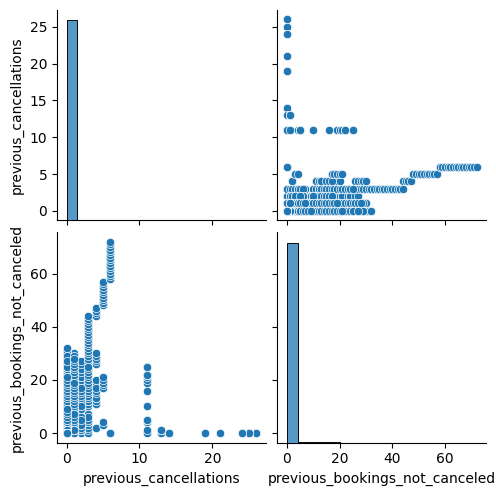

In [18]:
pairplot(dset[['previous_cancellations', 'previous_bookings_not_canceled']])

In [28]:
(dset['adr']<=0).sum()

1960

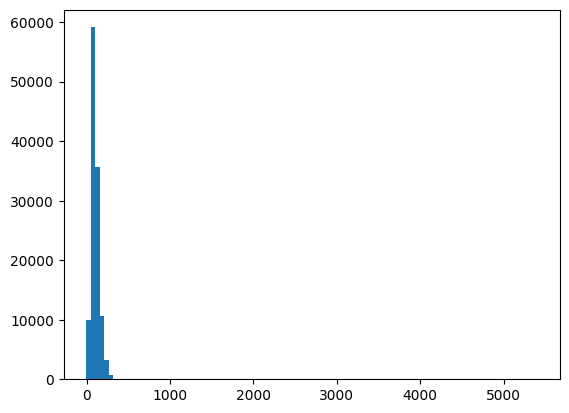

In [30]:
plt.hist(dset['adr'], bins=100)
plt.show()

In [38]:
pd.DataFrame(dset['adr'].value_counts()).sort_index

<bound method DataFrame.sort_index of         count
adr          
62.00    3754
75.00    2715
90.00    2473
65.00    2418
0.00     1959
...       ...
89.43       1
63.07       1
55.69       1
49.51       1
157.71      1

[8879 rows x 1 columns]>